In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

purchases = pd.read_csv("../analisis exploratorio/amazon-purchases.csv")
survey = pd.read_csv("../analisis exploratorio/survey2.csv")

MemoryError: Unable to allocate 84.7 MiB for an array with shape (6, 1850717) and data type object

In [ ]:
survey.drop(columns=["Q-life-changes"], inplace=True)

In [ ]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

In [ ]:
purchases_samsung = purchases[
    purchases["Title"].str.contains(r"\bsamsung\b", case=False, regex=True, na=False)
].copy()

purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19706 entries, 5 to 1850564
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                19706 non-null  object 
 1   Purchase Price Per Unit   19706 non-null  float64
 2   Quantity                  19706 non-null  float64
 3   Shipping Address State    19136 non-null  object 
 4   Title                     19706 non-null  object 
 5   ASIN/ISBN (Product Code)  19704 non-null  object 
 6   Category                  19699 non-null  object 
 7   Survey ResponseID         19706 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.4+ MB


In [ ]:
electronics_keywords = [
    r"\belectronics?\b",
    r"\bcomputer\b",
    r"\blaptop\b",
    r"\bnotebook\b",
    r"\bdesktop\b",
    r"\btablet\b",
    r"\bsmartphone\b",
    r"\bphone\b",
    r"\btv\b",
    r"\btelevision\b",
    r"\bmonitor\b",
    r"\bprojector\b",
    r"\bprinter\b",
    r"\bscanner\b",
    r"\bcamera\b",
    r"\bwebcam\b",
    r"\bspeaker\b",
    r"\baudio\b",
    r"\bsoundbar\b",
    r"\bheadphones?\b",
    r"\bheadset\b",
    r"\bearbuds?\b",
    r"\bmicrophone\b",
    r"\bcharger\b",
    r"\bcharging\b",
    r"\bbattery\b",
    r"\bpower(?: bank| supply)?\b",
    r"\badapter\b",
    r"\bcable\b",
    r"\bdock(?:ing)?(?: station)?\b",
    r"\bmouse\b",
    r"\bkeyboard\b",
    r"\btrackpad\b",
    r"\bcontroller\b",
    r"\bstylus\b",
    r"\bssd\b",
    r"\b(?:hard ?drive|hdd)\b",
    r"\b(?:flash ?drive|thumb ?drive)\b",
    r"\b(?:memory|ram)\b",
    r"\bgpu\b",
    r"\bgraphics card\b",
    r"\busb\b",
    r"\bbluetooth\b",
    r"\bhdmi\b",
    r"\bethernet\b",
    r"\b(?:wi[- ]?fi|wifi)\b",
    r"\bsmartwatch\b",
    r"\bwearable\b",
    r"\brouter\b",
    r"\bmodem\b",
    r"\bmesh(?: wifi)?\b",
    r"\btoner\b",
    r"\bink\b",
    r"\b(?:vr headset|virtual reality)\b"
]

In [ ]:
purchases_samsung = purchases_samsung[
    purchases_samsung["Title"].str.contains('|'.join(electronics_keywords), case=False, regex=True, na=False)
].copy()

In [ ]:
purchases_samsung = purchases_samsung.copy()

# Crear indicadores de ausencia antes de imputar
cols_con_nulos = [
    "Shipping Address State",
    "ASIN/ISBN (Product Code)",
    "Category"
]

for col in cols_con_nulos:
    purchases_samsung[f"{col}_missing"] = purchases_samsung[col].isna().astype(int)

# Imputación diferenciada
for col in ["Shipping Address State", "Category"]:
    moda = purchases_samsung[col].mode(dropna=True)[0]
    purchases_samsung[col] = purchases_samsung[col].fillna(moda)

purchases_samsung["ASIN/ISBN (Product Code)"] = (
    purchases_samsung["ASIN/ISBN (Product Code)"]
    .fillna("No informado")
)

purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 14364 entries, 5 to 1850564
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Order Date                        14364 non-null  object 
 1   Purchase Price Per Unit           14364 non-null  float64
 2   Quantity                          14364 non-null  float64
 3   Shipping Address State            14364 non-null  object 
 4   Title                             14364 non-null  object 
 5   ASIN/ISBN (Product Code)          14364 non-null  object 
 6   Category                          14364 non-null  object 
 7   Survey ResponseID                 14364 non-null  object 
 8   Shipping Address State_missing    14364 non-null  int32  
 9   ASIN/ISBN (Product Code)_missing  14364 non-null  int32  
 10  Category_missing                  14364 non-null  int32  
dtypes: float64(2), int32(3), object(6)
memory usage: 1.2+ MB


In [ ]:
purchases_samsung["Order Date"] = pd.to_datetime(purchases_samsung["Order Date"], errors="coerce")

In [ ]:
df_completo= pd.merge(
    purchases_samsung,
    survey,
    left_on="Survey ResponseID",
    right_on="Survey ResponseID"
)

In [ ]:
df_completo.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14364 entries, 0 to 14363
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Order Date                        14364 non-null  datetime64[ns]
 1   Purchase Price Per Unit           14364 non-null  float64       
 2   Quantity                          14364 non-null  float64       
 3   Shipping Address State            14364 non-null  object        
 4   Title                             14364 non-null  object        
 5   ASIN/ISBN (Product Code)          14364 non-null  object        
 6   Category                          14364 non-null  object        
 7   Survey ResponseID                 14364 non-null  object        
 8   Shipping Address State_missing    14364 non-null  int32         
 9   ASIN/ISBN (Product Code)_missing  14364 non-null  int32         
 10  Category_missing                  14364 non-nu

C:\Users\jeam2\AppData\Local\Temp\ipykernel_20564\2510975686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x=df_completo["Q-amazon-use-howmany"].value_counts().index,


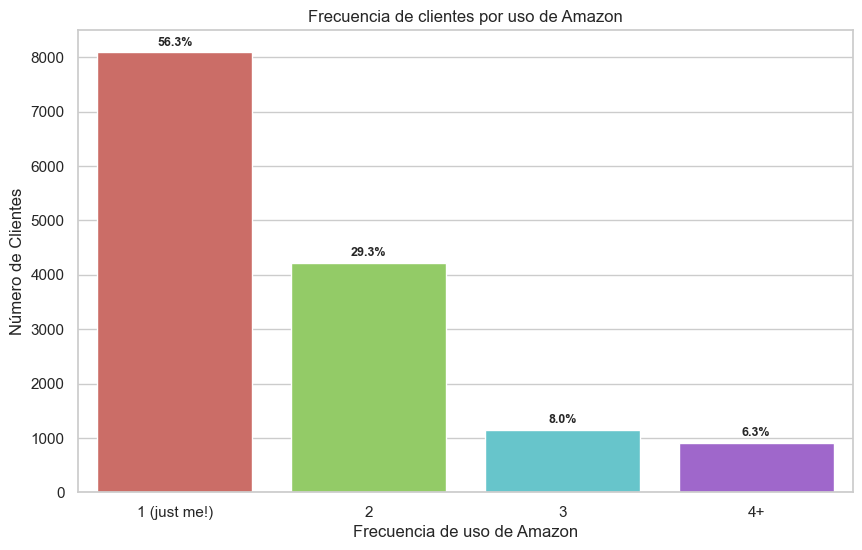

In [ ]:
# Gráfico de barras con porcentajes
plt.figure(figsize=(10,6))
ax =sns.barplot(x=df_completo["Q-amazon-use-howmany"].value_counts().index,
            y=df_completo["Q-amazon-use-howmany"].value_counts().values,
             palette="hls")
total_clientes = df_completo["Q-amazon-use-howmany"].value_counts().sum()
# 6. Añadir los porcentajes encima de cada barra (ahora sumarán el 100%)
for bar in ax.patches:
    altura = bar.get_height()
    if altura > 0:
        porcentaje = (altura / total_clientes) * 100
        # Coloca el texto centrado justo arriba de la barra
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            altura + (total_clientes * 0.005),   # Margen dinámico para el texto
            f'{porcentaje:.1f}%',                
            ha='center', 
            va='bottom', 
            fontsize=9, 
            fontweight='bold'
        )
plt.title("Frecuencia de clientes por uso de Amazon")

plt.xlabel("Frecuencia de uso de Amazon")
plt.ylabel("Número de Clientes")
plt.show()

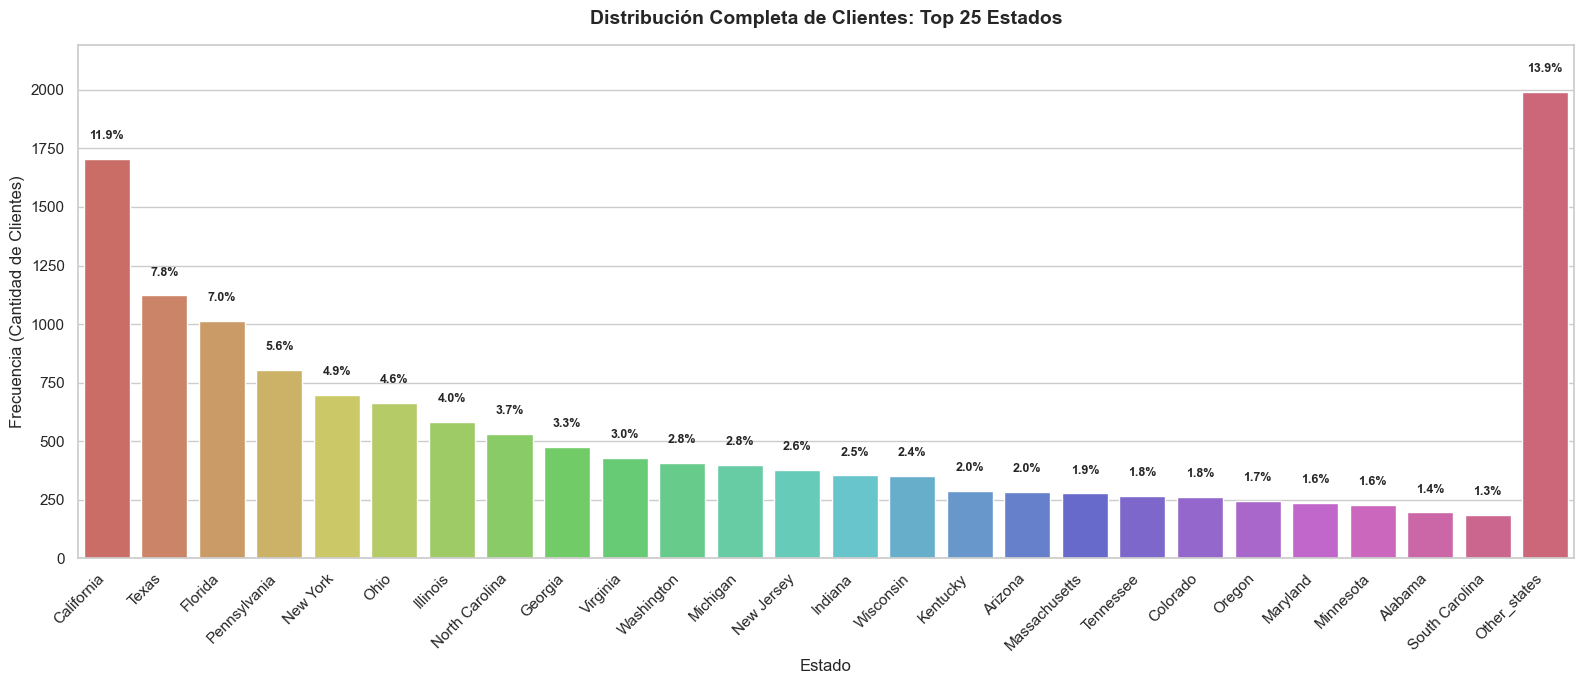

In [ ]:
# 1. Obtener todas las frecuencias y el total global
todos_los_estados = df_completo["Q-demos-state"].value_counts()
total_clientes = todos_los_estados.sum()

# 2. Separar el Top 25 y calcular el grupo "Otros"
top_25 = todos_los_estados.head(25)
otros_total = total_clientes - top_25.sum()

# 3. Crear una nueva serie de Pandas combinando el Top 25 con "Otros"
# Usamos pd.concat para asegurar la compatibilidad con las últimas versiones de pandas
otros_series = pd.Series([otros_total], index=["Other_states"])
datos_completos = pd.concat([top_25, otros_series])

# 4. Configurar el tamaño de la figura (un poco más ancha para la nueva barra)
plt.figure(figsize=(16, 7))

# 5. Crear el gráfico de barras
ax = sns.barplot(
    x=datos_completos.index, 
    y=datos_completos.values, 
    hue=datos_completos.index, 
    palette="hls", 
    legend=False
)

# 6. Añadir los porcentajes encima de cada barra (ahora sumarán el 100%)
for bar in ax.patches:
    altura = bar.get_height()
    if altura > 0:
        porcentaje = (altura / total_clientes) * 100
        # Coloca el texto centrado justo arriba de la barra
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            altura + (total_clientes * 0.005),   # Margen dinámico para el texto
            f'{porcentaje:.1f}%',                
            ha='center', 
            va='bottom', 
            fontsize=9, 
            fontweight='bold'
        )

# 7. Estética, títulos y etiquetas
plt.title("Distribución Completa de Clientes: Top 25 Estados", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Estado", fontsize=12)
plt.ylabel("Frecuencia (Cantidad de Clientes)", fontsize=12)

# Ajustamos el límite superior en Y para que no se corten las etiquetas de arriba
plt.ylim(0, max(datos_completos.values) * 1.1)

# Rotación de los nombres de los estados
plt.xticks(rotation=45, ha="right")

# Ajuste automático de los márgenes para que todo sea visible
plt.tight_layout()

# Mostrar gráfico
plt.show()

C:\Users\jeam2\AppData\Local\Temp\ipykernel_20564\1583102494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x=df_completo["Q-demos-age"].value_counts().index,


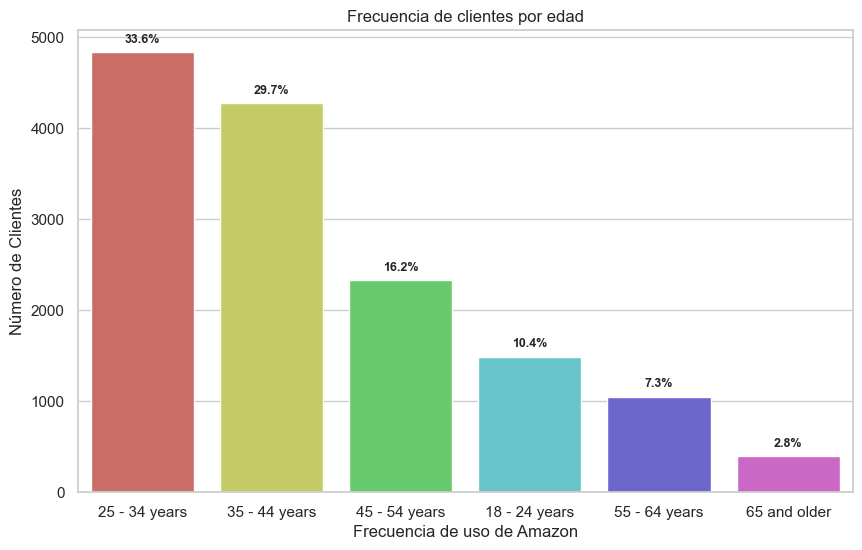

In [ ]:
# Gráfico de barras con porcentajes para edades
plt.figure(figsize=(10,6))
ax =sns.barplot(x=df_completo["Q-demos-age"].value_counts().index,
            y=df_completo["Q-demos-age"].value_counts().values,
             palette="hls")
total_clientes = df_completo["Q-demos-age"].value_counts().sum()
# 6. Añadir los porcentajes encima de cada barra (ahora sumarán el 100%)
for bar in ax.patches:
    altura = bar.get_height()
    if altura > 0:
        porcentaje = (altura / total_clientes) * 100
        # Coloca el texto centrado justo arriba de la barra
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            altura + (total_clientes * 0.005),   # Margen dinámico para el texto
            f'{porcentaje:.1f}%',                
            ha='center', 
            va='bottom', 
            fontsize=9, 
            fontweight='bold'
        )
plt.title("Frecuencia de clientes por edad")

plt.xlabel("Frecuencia de uso de Amazon")
plt.ylabel("Número de Clientes")
plt.show()

In [ ]:
# Conteo de categorías
conteo_gender = df[col].value_counts(dropna=False)

# Gráfica de barras
plt.figure(figsize=(8, 5))
conteo_gender.plot(kind="bar")

plt.title("Distribución de género")
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

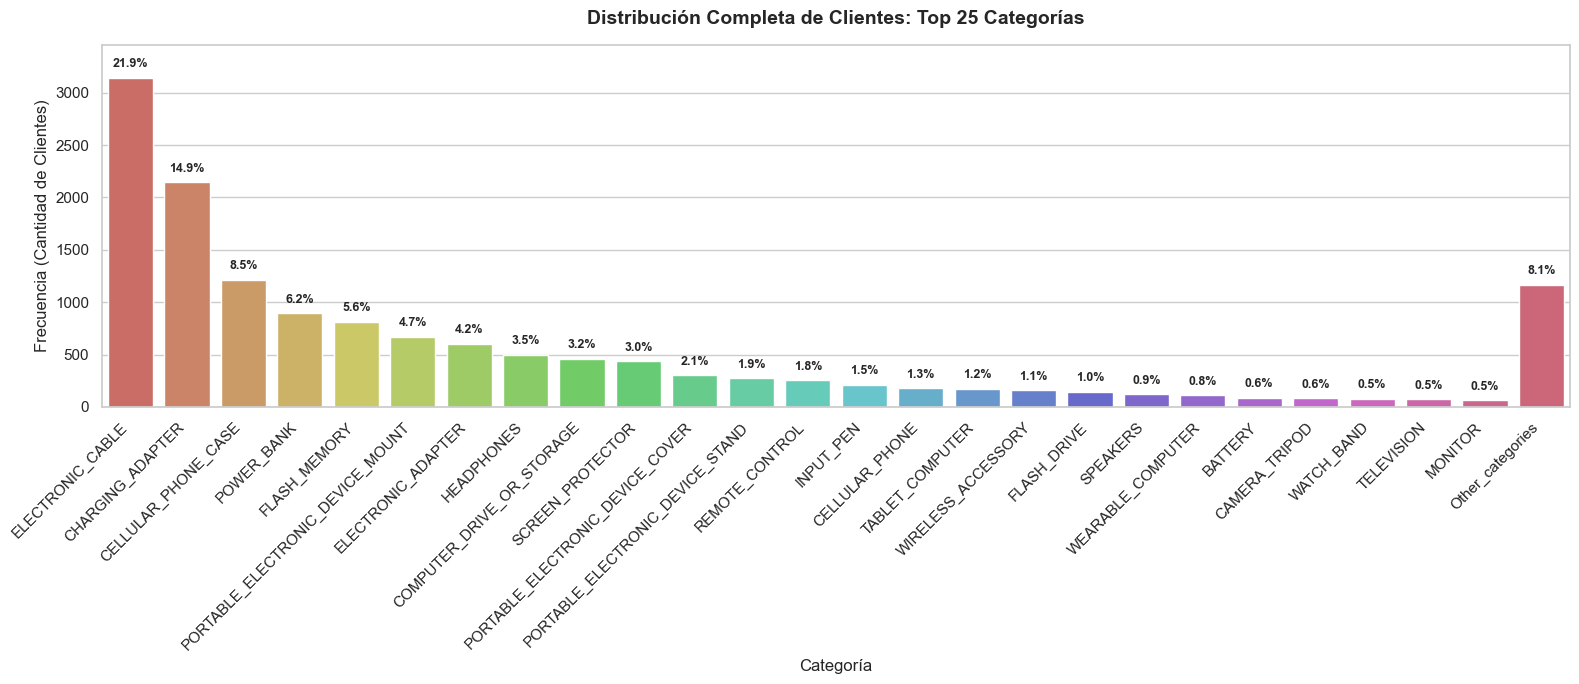

In [ ]:
# 1. Obtener todas las frecuencias y el total global
todos_las_categorias = df_completo["Category"].value_counts()
total_clientes = todos_las_categorias.sum()

# 2. Separar el Top 25 y calcular el grupo "Otros"
top_25 = todos_las_categorias.head(25)
otros_total = total_clientes - top_25.sum()

# 3. Crear una nueva serie de Pandas combinando el Top 25 con "Otros"
# Usamos pd.concat para asegurar la compatibilidad con las últimas versiones de pandas
otros_series = pd.Series([otros_total], index=["Other_categories"])
datos_completos = pd.concat([top_25, otros_series])

# 4. Configurar el tamaño de la figura (un poco más ancha para la nueva barra)
plt.figure(figsize=(16, 7))

# 5. Crear el gráfico de barras
ax = sns.barplot(
    x=datos_completos.index, 
    y=datos_completos.values, 
    hue=datos_completos.index, 
    palette="hls", 
    legend=False
)

# 6. Añadir los porcentajes encima de cada barra (ahora sumarán el 100%)
for bar in ax.patches:
    altura = bar.get_height()
    if altura > 0:
        porcentaje = (altura / total_clientes) * 100
        # Coloca el texto centrado justo arriba de la barra
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            altura + (total_clientes * 0.005),   # Margen dinámico para el texto
            f'{porcentaje:.1f}%',                
            ha='center', 
            va='bottom', 
            fontsize=9, 
            fontweight='bold'
        )

# 7. Estética, títulos y etiquetas
plt.title("Distribución Completa de Clientes: Top 25 Categorías", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Frecuencia (Cantidad de Clientes)", fontsize=12)

# Ajustamos el límite superior en Y para que no se corten las etiquetas de arriba
plt.ylim(0, max(datos_completos.values) * 1.1)

# Rotación de los nombres de los estados
plt.xticks(rotation=45, ha="right")

# Ajuste automático de los márgenes para que todo sea visible
plt.tight_layout()

# Mostrar gráfico
plt.show()

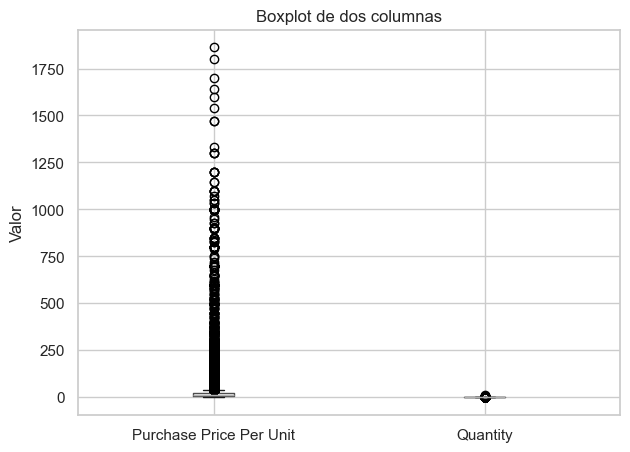

In [ ]:
# Boxplot de price y quantity
cols = ["Purchase Price Per Unit", "Quantity"]

purchases_samsung[cols].boxplot(figsize=(7, 5))
plt.title("Boxplot de dos columnas")
plt.ylabel("Valor")
plt.show()